# Churn Early-Warning: walkthrough

A guided tour of the capstone for reviewers. Every cell calls the tested package in `src/segar_churn`; nothing here is logic the repo doesn't already test.

**In Colab:** run the first cell to clone the repo and build everything (~1 min).

In [1]:
import os, sys, json
if 'google.colab' in sys.modules and not os.path.exists('segar-churn-early-warning'):
    !git clone <your-repo-url> segar-churn-early-warning
    %cd segar-churn-early-warning
    !pip -q install -r requirements.txt
    !PYTHONPATH=src python -m segar_churn.pipeline
ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, 'src'))
import pandas as pd
from IPython.display import Image, Markdown, display
from segar_churn import config as C
print('repo root:', ROOT)

repo root: /home/claude/segar-churn-early-warning


## 1. Is the data trustworthy? (Checkpoint 1)

In [2]:
display(Markdown((C.REPORTS / 'data_quality_log.md').read_text()))

# Data quality log

Generated by `make checks` (src/segar_churn/data_checks.py). Re-run after any data refresh.

| Table | Rule | Severity | Rows affected | Action |
|---|---|---|---:|---|
| outlets | required columns present (8) | ✅ BLOCK | 0 | ok |
| orders | required columns present (7) | ✅ BLOCK | 0 | ok |
| visits | required columns present (3) | ✅ BLOCK | 0 | ok |
| complaints | required columns present (3) | ✅ BLOCK | 0 | ok |
| outlets | outlet_id unique | ✅ BLOCK | 0 | ok |
| outlets | outlet_type in allowed set | ✅ BLOCK | 0 | ok |
| outlets | city not null | 🛠️ FIX | 26 | filled with 'Unknown' (city is not a model feature) |
| orders | order_date parseable | ✅ FIX | 0 | dropped |
| orders | gross_value_idr > 0 | 🛠️ FIX | 12 | dropped (credit notes keyed as orders; finance confirmed they belong in returns) |
| orders | order_date <= 2026-09-30 | 🛠️ FIX | 3 | dropped (year typo, e.g. 2027 for 2025) |
| orders | no exact duplicate rows | 🛠️ FIX | 520 | dropped duplicates (ERP double-posting) |
| orders | invoice_id unique after de-dup | ✅ BLOCK | 0 | ok |
| orders | outlet_id exists in outlet master | ✅ BLOCK | 0 | ok |
| orders | discount_pct between 0 and 0.5 | ✅ WARN | 0 | reported only |
| orders | days_paid_late >= 0 | ✅ BLOCK | 0 | ok |
| orders | no extreme order values (>5x p99.9) | ✅ WARN | 0 | reported only |
| visits | outlet_id exists in outlet master | ✅ BLOCK | 0 | ok |
| complaints | outlet_id exists in outlet master | ✅ BLOCK | 0 | ok |
| orders | no month with <50% of median order volume | ✅ WARN | 0 | reported only |

## Row counts

| Table | Raw | Clean |
|---|---:|---:|
| outlets | 2,600 | 2,600 |
| orders | 174,334 | 173,799 |
| visits | 77,891 | 77,891 |
| complaints | 6,341 | 6,341 |


## 2. Is the problem real, and is it changing?

60-day churn: 9.0% (95% CI 7.8%–10.3%), n=1990
H1_late_payers: p = 3.7e-33  (Do outlets paying >14 days late on average churn more?)
H2_sku_shrink: p = 9.0e-25  (Is SKU-range change lower (shrinking) for outlets that go on to churn?)
H3_no_visit: p = 5.4e-30  (Do outlets with zero rep visits in 60 days churn more?)
H4_region: p = 9.0e-13  (Does churn rate differ by region?)


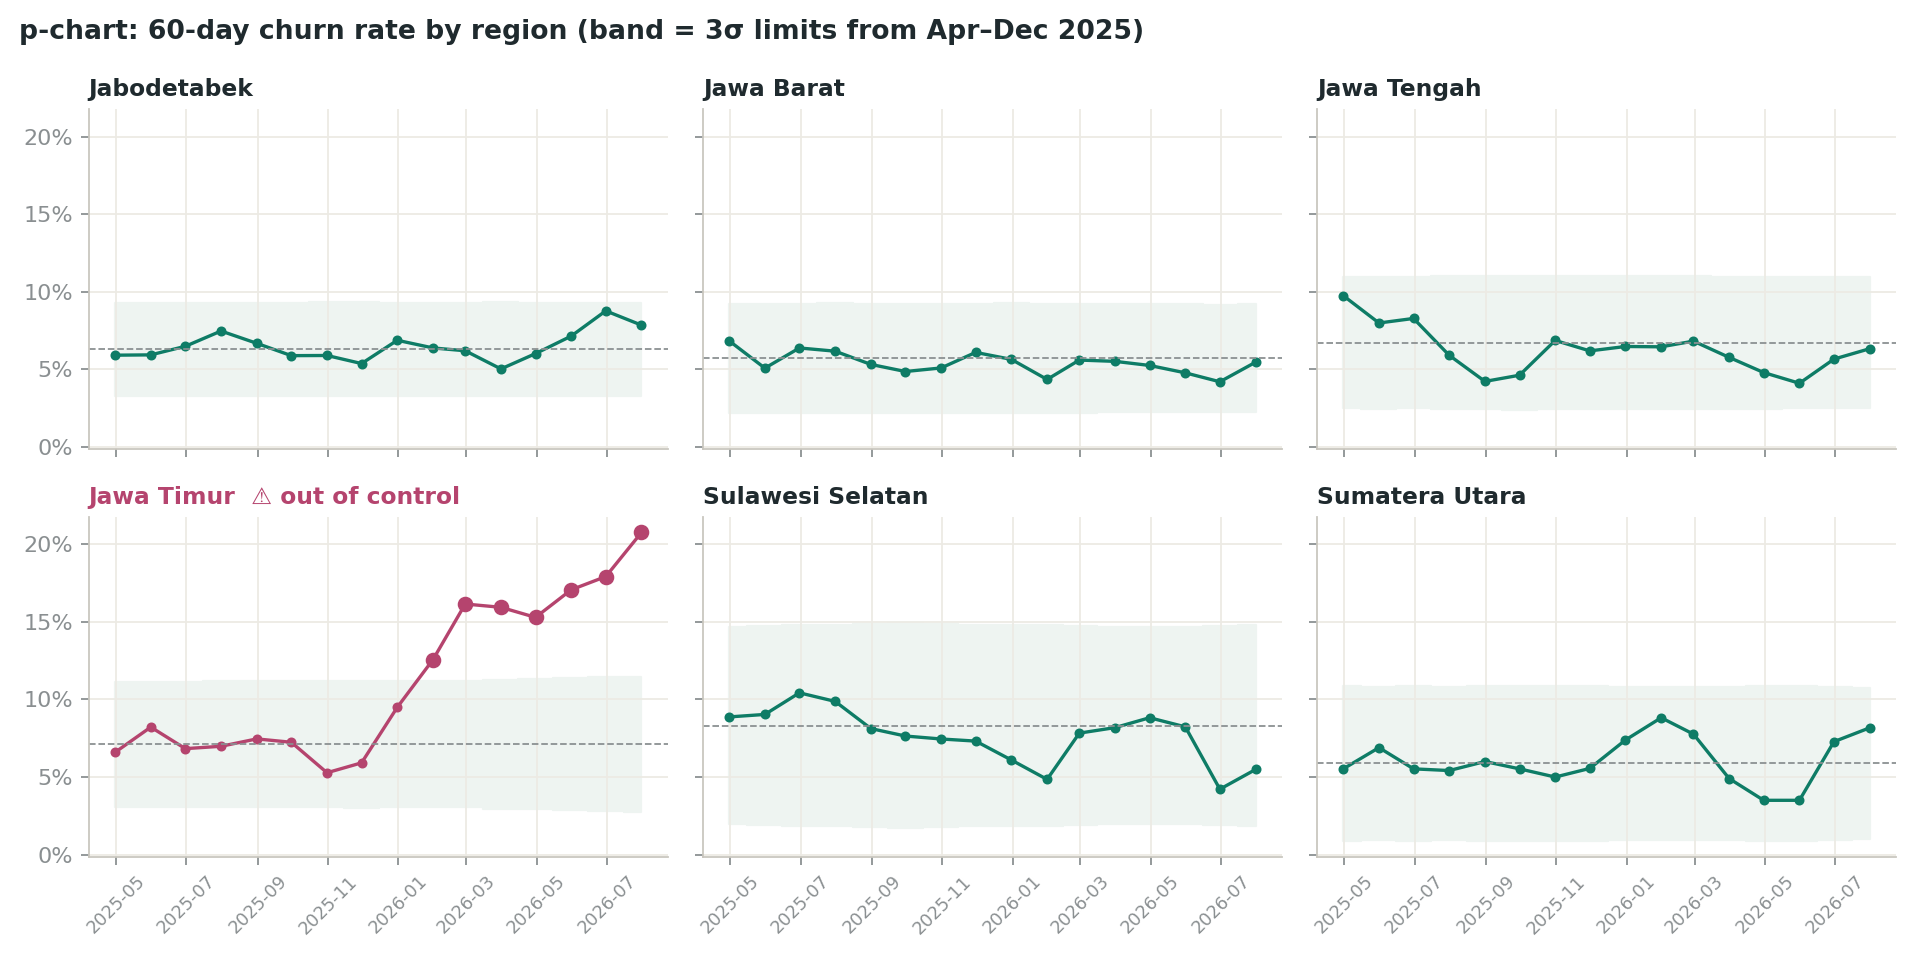

In [3]:
ev = json.loads((C.REPORTS / 'evidence.json').read_text())
r = ev['churn_rate']
print(f"60-day churn: {r['rate']:.1%} (95% CI {r['ci95'][0]:.1%}–{r['ci95'][1]:.1%}), n={r['n']}")
for h in ['H1_late_payers', 'H2_sku_shrink', 'H3_no_visit', 'H4_region']:
    print(f"{h}: p = {ev[h]['p_value']:.1e}  ({ev[h]['question']})")
display(Image(C.FIGURES / 'p_chart_region.png'))

## 3. Does the model beat what the team does today? (Checkpoint 2A)

,revenue_captured_at_k,precision_at_k,churners_caught_at_k,roc_auc,pr_auc
baseline_recency,0.439,0.477,0.576,0.830,0.509
baseline_rule_30d_by_revenue,0.474,0.462,0.559,0.823,0.403
logistic_regression,0.700,0.258,0.314,0.888,0.602
logistic_regression_prob_only,0.355,0.495,0.598,0.888,0.602
gradient_boosting,0.724,0.288,0.350,0.902,0.640
gradient_boosting_prob_only,0.489,0.518,0.626,0.902,0.640


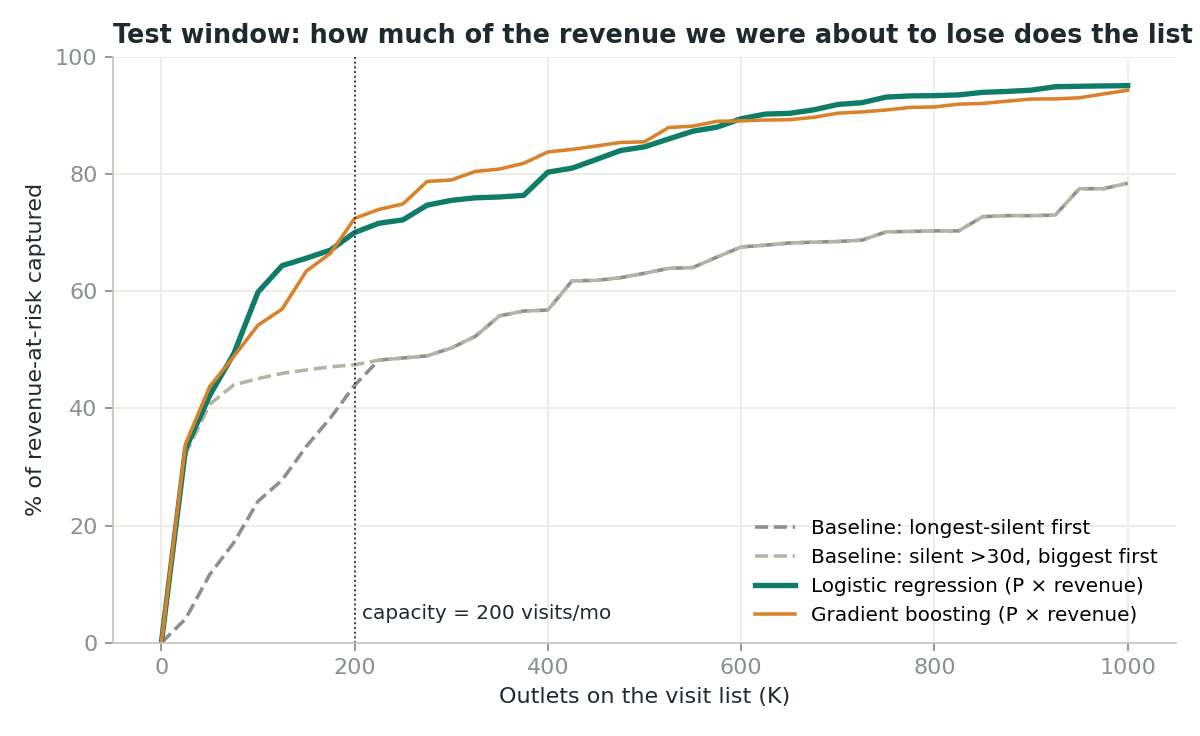

In [4]:
m = json.loads((C.REPORTS / 'metrics.json').read_text())
cols = ['revenue_captured_at_k', 'precision_at_k', 'churners_caught_at_k', 'roc_auc', 'pr_auc']
display(pd.DataFrame(m['test']).T[cols].round(3))
display(Image(C.FIGURES / 'gains_revenue_captured.png'))

Ranking by probability only (`*_prob_only`) **loses** to the recency baseline on revenue. Ranking by expected revenue lost is what makes the product work.

## 4. The deployed policy after stakeholder pushback (Checkpoint 3)

In [5]:
display(pd.DataFrame(m['test_policy_comparison']).T.round(3))

,revenue_captured_at_k,precision_at_k,churners_caught_at_k,warung_churners_caught
today_recency_baseline,0.439,0.477,0.576,0.528
v1.0_pure_expected_revenue,0.700,0.258,0.314,0.000
v1.1_plus_40_warung_slots,0.670,0.372,0.452,0.337
v1.2_plus_floor_0.05,0.686,0.438,0.532,0.342


## 5. Who does the list reach? (bias review, Checkpoint 2B)

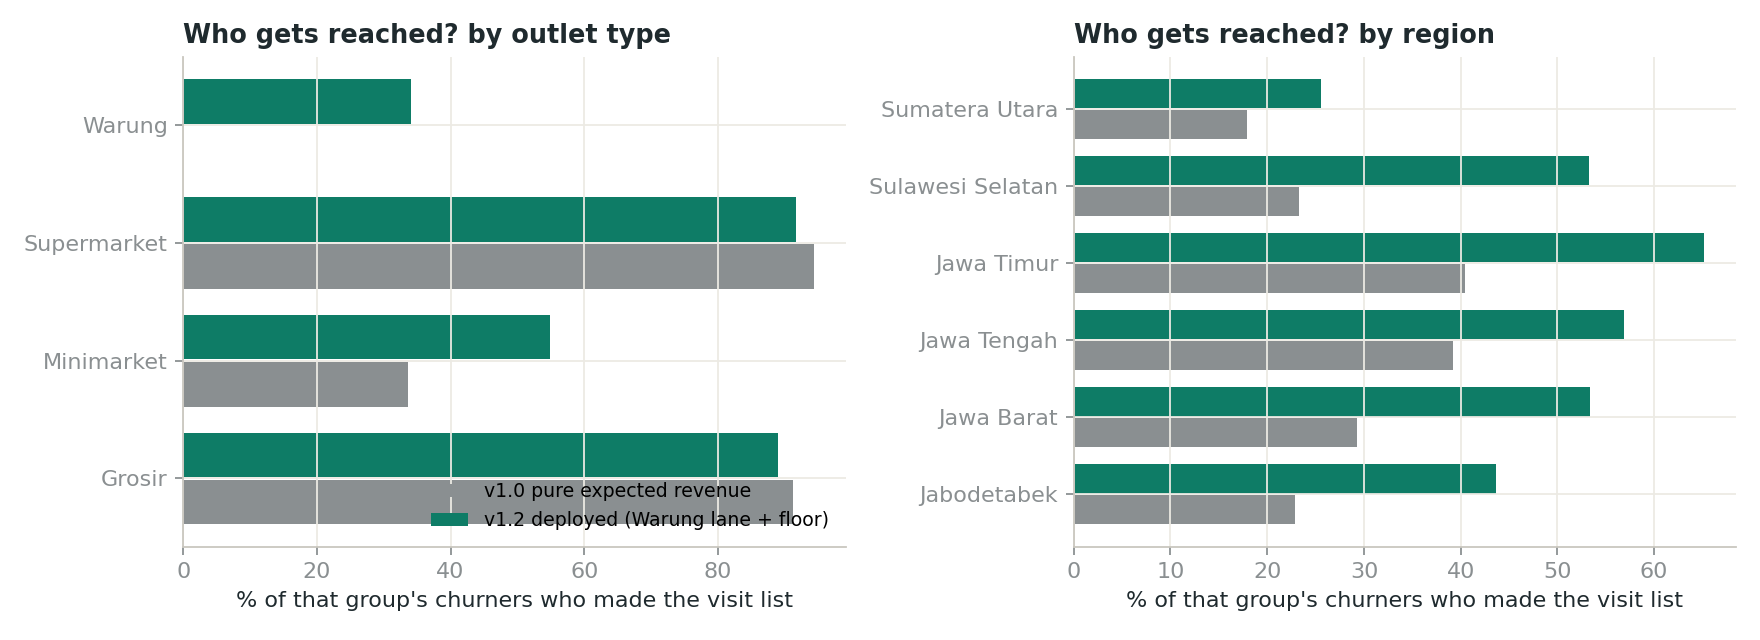

In [6]:
display(Image(C.FIGURES / 'bias_review.png'))

## 6. This month's visit list

In [7]:
vl = pd.read_csv(C.OUTPUTS / 'visit_list_2026-09-30.csv')
display(vl[['priority_rank','lane','outlet_name','outlet_type','region','churn_probability','revenue_at_stake_m','expected_loss_m','reason_1','action']].head(15))
print(vl.groupby('region').size().sort_values(ascending=False))

,priority_rank,lane,outlet_name,outlet_type,region,churn_probability,revenue_at_stake_m,expected_loss_m,reason_1,action
0,1.0,Revenue lane,Swalayan Barokah Pekalongan 1,Supermarket,Jawa Tengah,0.7302,528.044,385.5734,No order for 40 days,Call this week to confirm next order; check sh...
1,2.0,Revenue lane,Supermarket Barokah Depok,Supermarket,Jabodetabek,0.1767,992.724,175.3990,No rep visit on record,Book a rep visit within 7 days
2,3.0,Revenue lane,Swalayan Bahagia Sidoarjo,Supermarket,Jawa Timur,0.2204,777.512,171.3445,No order for 14 days,Call this week to confirm next order; check sh...
3,4.0,Revenue lane,Swalayan Tunas Baru Sidoarjo,Supermarket,Jawa Timur,0.5621,286.512,161.0447,No order for 33 days,Call this week to confirm next order; check sh...
4,5.0,Revenue lane,UD Segar Jaya Cirebon,Grosir,Jawa Barat,0.6598,232.168,153.1907,No order for 47 days,Call this week to confirm next order; check sh...
5,6.0,Revenue lane,Toko Grosir Setia Kawan,Grosir,Jawa Timur,0.5094,266.664,135.8458,No order for 42 days,Call this week to confirm next order; check sh...
6,7.0,Revenue lane,Supermarket Damai 5,Supermarket,Jabodetabek,0.1857,731.100,135.7579,No order for 22 days,Call this week to confirm next order; check sh...
7,8.0,Revenue lane,Swalayan Maju Jaya Gresik,Supermarket,Jawa Timur,0.9671,112.348,108.6569,No order for 69 days,Call this week to confirm next order; check sh...
8,9.0,Revenue lane,Toko Grosir Makmur Semarang,Grosir,Jawa Tengah,0.5358,196.932,105.5181,No order for 42 days,Call this week to confirm next order; check sh...
9,10.0,Revenue lane,Grosir Bintang Timur Gresik,Grosir,Jawa Timur,0.4969,200.684,99.7150,No order for 51 days,Call this week to confirm next order; check sh...


region
Jawa Timur          80
Jabodetabek         34
Jawa Barat          29
Jawa Tengah         27
Sulawesi Selatan    18
Sumatera Utara      12
dtype: int64


## 7. Drift check

PSI < 0.10 stable · 0.10–0.25 watch · > 0.25 investigate.

In [8]:
display(pd.read_csv(C.OUTPUTS / 'drift_report_2026-09-30.csv'))

,feature,label,psi,status
0,tenure_months,New partner (short tenure),0.2173,Watch
1,avg_days_late_90d,Paying invoices late,0.0184,Stable
2,sku_breadth_90d,Distinct SKUs bought,0.0099,Stable
3,share_late_14_90d,Share of invoices >14 days late,0.0085,Stable
4,region,Region,0.0077,Stable
5,avg_discount_pct_90d,Discount dependence,0.0076,Stable
6,visits_60d,Few sales-rep visits,0.0064,Stable
7,recency_days,Days since last order,0.0063,Stable
8,order_trend,Order frequency trend,0.0059,Stable
9,avg_order_value_k,Average order value,0.0056,Stable


Open `app/dashboard.html` for the stakeholder view.